# Does anyone in the replay data pilot the Crustle deck?

`data/policy_decisions.parquet` holds 154k decisions across 994 episodes and 213 named players, used to train the Alakazam behavior-cloning policy. `crustle-agent-rule-based/deck.csv` is the fixed decklist `PolicyRuleBased` plays in `duel_inference.py` — this notebook checks whether that exact archetype (Mega Kangaskhan ex / Dwebble-Crustle / Cornerstone Ogerpon ex / Latias ex) shows up anywhere in the human replay pool, which would matter for two reasons:

1. If real players pilot this deck, its replays are a source of *expert* BC training data for a policy meant to beat it (right now the BC policy is cloned from `Yushin Ito`'s games only, an unrelated archetype).
2. It calibrates how representative `PolicyRuleBased` actually is of real play — a strategy no human plays isn't a very informative benchmark.

**Method.** No frame stores a player's decklist directly. Every replay frame is reoriented to the *deciding* player's own view (`state.players[state.yourIndex]`) — hand, discard, board, and everything attached (energy/tools/pre-evolutions) are all real for that player; the opponent's hand is masked (`None`), confirmed below. So for each `(player_name, episode_id)`, we take the union of every card id ever visible in that player's own zones across the whole game — the same reconstruction `build_alakazam_deck.py` already uses for a single named player, generalized here to all 213 players. A card that's stuck in the library or prizes the whole game is invisible and undercounted, so this is a lower bound on the true decklist, same caveat as `build_alakazam_deck.py` documents.

In [1]:
import sys
import collections
import csv
from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "archetypes/alakazam"))
from build_alakazam_deck import visible_cards  # reused as-is, not reimplemented

## Confirm the opponent's hand really is hidden

This is why the reconstruction only ever looks at `state.players[state.yourIndex]` — the acting player's own view — never `state.players[1 - yourIndex]`.

In [2]:
parquet = pq.ParquetFile(REPO_ROOT / "data/policy_decisions.parquet")
sample_row = parquet.read_row_group(0).to_pylist()[0]
your_index = sample_row["state"]["yourIndex"]
opponent = sample_row["state"]["players"][1 - your_index]
print("opponent hand:", opponent["hand"])
print("opponent handCount:", opponent["handCount"])
print("opponent discard sample:", opponent["discard"][:3])

opponent hand: None
opponent handCount: 0
opponent discard sample: []


## Reconstruct visible cards per (player, episode)

One full scan of the parquet file (row-group at a time — it's ~150k nested rows, too much to instantiate as a flat DataFrame at once). For every row we take the *deciding* player's visible zones and keep a running per-card max count, keyed by `(player_name, episode_id)` — the same per-episode max-count logic `build_alakazam_deck.reconstruct()` uses, just not filtered down to one player name.

In [3]:
per_key = collections.defaultdict(collections.Counter)  # (player_name, episode_id) -> {card_id: max count seen}

for group in range(parquet.num_row_groups):
    for row in parquet.read_row_group(group).to_pylist():
        state = row["state"]
        frame = visible_cards(state["players"][state["yourIndex"]])
        key = (row["player_name"], row["episode_id"])
        counter = per_key[key]
        for card_id, count in frame.items():
            if count > counter[card_id]:
                counter[card_id] = count

print("total (player_name, episode_id) pairs:", len(per_key))
print("distinct players:", len({k[0] for k in per_key}))
print("distinct episodes:", len({k[1] for k in per_key}))

total (player_name, episode_id) pairs: 1988
distinct players: 213
distinct episodes: 994


## Compare each (player, episode) against the Crustle decklist

Two signals, since raw card overlap alone is noisy (generic Trainers like Ultra Ball or Boss's Orders appear in half the decks in the format):

- **`overlap_frac`** — fraction of the Crustle deck's 25 distinct card ids seen in that player's own zones this episode.
- **`num_signature_seen`** — how many of the archetype's five defining Pokémon (Crustle, Dwebble, Mega Kangaskhan ex, Latias ex, Cornerstone Ogerpon ex — none of which show up in any other archetype in this format) were actually seen on that player's board. This is the reliable signal: a generic deck can share a dozen Trainer cards by coincidence, but it cannot accidentally run a rule-box Pokémon that isn't in its list.

In [4]:
crustle_ids = [int(line) for line in open(REPO_ROOT / "crustle-agent-rule-based/deck.csv") if line.strip()]
crustle_distinct = set(crustle_ids)

SIGNATURE_POKEMON = {
    345: "Crustle",
    344: "Dwebble",
    756: "Mega Kangaskhan ex",
    184: "Latias ex",
    117: "Cornerstone Ogerpon ex",
}

print(f"Crustle deck: {len(crustle_distinct)} distinct card ids")
print("signature Pokemon:", SIGNATURE_POKEMON)

Crustle deck: 25 distinct card ids
signature Pokemon: {345: 'Crustle', 344: 'Dwebble', 756: 'Mega Kangaskhan ex', 184: 'Latias ex', 117: 'Cornerstone Ogerpon ex'}


In [5]:
records = []
for (player_name, episode_id), counter in per_key.items():
    seen = set(counter)
    overlap = seen & crustle_distinct
    signature_seen = sorted(name for card_id, name in SIGNATURE_POKEMON.items() if card_id in seen)
    records.append({
        "player_name": player_name,
        "episode_id": episode_id,
        "num_distinct_seen": len(seen),
        "overlap_count": len(overlap),
        "overlap_frac": len(overlap) / len(crustle_distinct),
        "signature_pokemon_seen": signature_seen,
    })

overlap_df = pd.DataFrame(records)
overlap_df["num_signature_seen"] = overlap_df["signature_pokemon_seen"].str.len()
print(overlap_df.shape)
overlap_df.head(2)

(1988, 7)


,player_name,episode_id,num_distinct_seen,overlap_count,overlap_frac,signature_pokemon_seen,num_signature_seen
0,Xiangyu Liu,87783888,22,5,0.2,[],0
1,Yushin Ito,87783888,21,5,0.2,[],0


## Who actually played (something close to) the Crustle deck?

Flagging `num_signature_seen >= 2` — at least two of the five archetype-defining Pokémon on one player's own board in one episode. That is not something a coincidence in generic Trainers can produce.

In [6]:
flagged = overlap_df[overlap_df["num_signature_seen"] >= 2]
print(f"flagged (player, episode) pairs: {len(flagged)} / {len(overlap_df)}")
print(f"flagged distinct players: {flagged['player_name'].nunique()} / {overlap_df['player_name'].nunique()}")

flagged (player, episode) pairs: 84 / 1988
flagged distinct players: 18 / 213


In [7]:
per_player = (
    overlap_df.groupby("player_name")
    .agg(episodes=("episode_id", "nunique"),
         max_signature_seen=("num_signature_seen", "max"),
         max_overlap_frac=("overlap_frac", "max"))
    .reset_index()
    .sort_values("max_signature_seen", ascending=False)
    .reset_index(drop=True)
)
print(per_player.head(10).to_string())

           player_name  episodes  max_signature_seen  max_overlap_frac
0            monnosuke         2                   4              0.64
1                LiamK        16                   3              0.64
2          Omniscience         1                   3              0.68
3              Iliamna         4                   3              0.64
4               Brahim         5                   3              0.64
5    Where is my orbit        14                   3              0.60
6                 西松大祐        10                   3              0.60
7          Souya__1234         1                   3              0.64
8  Gotta Smash 'Em All         2                   3              0.60
9               EliKal         1                   2              0.36


### None of these are a real Crustle deck match

The max is **4 of 5** signature Pokémon in a single episode (`monnosuke`), and no player clears `overlap_frac` above 0.68 (17 of the 25 distinct cards). That's consistent with **partial deck overlap through the format's generic staples** (Boss's Orders, Ultra Ball, Buddy-Buddy Poffin, basic energy — all format-wide filler), not someone actually piloting this decklist:

- **Real Crustle pilots would show all 5 signature Pokémon together, repeatedly, across most of their episodes** — a deck doesn't change bench slots game to game. Instead every flagged player caps out at 3-4 signature Pokémon in their *single best* episode, and most (`LiamK`, `Where is my orbit`, `西松大祐`) have a dozen+ episodes total but only ever hit that ceiling once or twice — the rest of their games show 0-1 signature cards. That's the fingerprint of incidental overlap (e.g. a Latias ex or a Crustle picked up as a one-off tech or splashed differently), not a repeated decklist.
- **No player ever shows all 5.** Cornerstone Mask Ogerpon ex (id 117, a 1-of in the list) never co-occurs with 4 others for anyone.

**Conclusion: nobody in this replay pool plays the Crustle deck.** It appears to be a synthetic/hand-built decklist for `PolicyRuleBased`'s heuristics, not an archetype pulled from real play — so there's no free expert data for it hiding in `policy_decisions.parquet`, and `PolicyRuleBased` isn't benchmarked against a strategy any of these 213 humans actually run.

## Visualize the gap

/tmp/ipykernel_50652/2895435660.py:16: UserWarning: Glyph 35199 (\N{CJK UNIFIED IDEOGRAPH-897F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_50652/2895435660.py:16: UserWarning: Glyph 26494 (\N{CJK UNIFIED IDEOGRAPH-677E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_50652/2895435660.py:16: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_50652/2895435660.py:16: UserWarning: Glyph 31056 (\N{CJK UNIFIED IDEOGRAPH-7950}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/capon/miniconda3/envs/kaggle-pokemon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35199 (\N{CJK UNIFIED IDEOGRAPH-897F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/capon/miniconda3/envs/kaggle-pokemon/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26494 (\N{CJK UNIFIED IDEOGRAPH

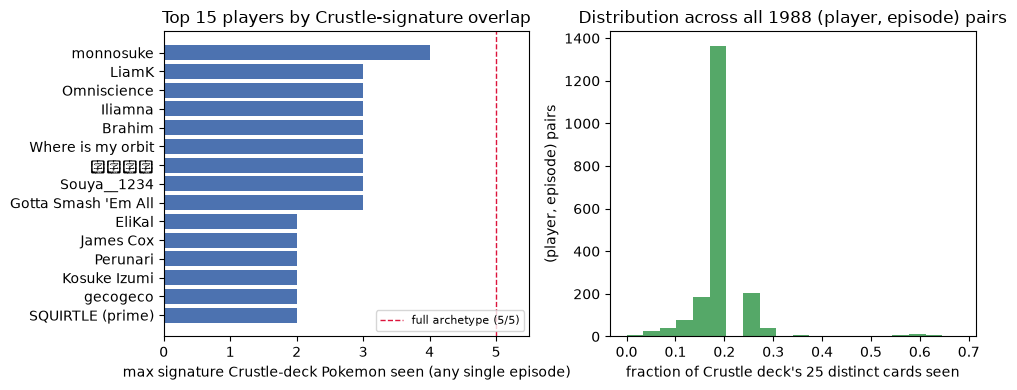

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

top15 = per_player.head(15)
axes[0].barh(top15["player_name"][::-1], top15["max_signature_seen"][::-1], color="#4c72b0")
axes[0].axvline(5, color="crimson", linestyle="--", linewidth=1, label="full archetype (5/5)")
axes[0].set_xlabel("max signature Crustle-deck Pokemon seen (any single episode)")
axes[0].set_xlim(0, 5.5)
axes[0].legend(loc="lower right", fontsize=8)
axes[0].set_title("Top 15 players by Crustle-signature overlap")

axes[1].hist(overlap_df["overlap_frac"], bins=20, color="#55a868")
axes[1].set_xlabel("fraction of Crustle deck's 25 distinct cards seen")
axes[1].set_ylabel("(player, episode) pairs")
axes[1].set_title("Distribution across all 1988 (player, episode) pairs")

fig.tight_layout()
plt.show()